# Import Ntuple

In [1]:
%load_ext autoreload
%autoreload 2

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
# sys.path.insert(0, "/home/belle/zhangboy/B2SW/2025_VirginiaTech/sysvar/src/")
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util

training_variables = util.training_variables
columns = util.all_relevant_variables
cut = util.offline_cut
lgb_tight = util.lgb_tight
lgb_loose = util.lgb_loose
lgb_comb = util.lgb_comb

In [2]:
# 4S Data vs MC
# (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0) and 1.855<D_M<1.885

# Load data files
MC_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_mu_3.root:MC_mu_loose'],
                          library="np",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_mu_3.root:Data_mu_loose'],
                          library="np",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

df_mc_4S_loose = pd.DataFrame(MC_4S_loose)
df_data_4S_loose = pd.DataFrame(data_4S_loose)

pi0_eff_table = '/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/pi0_eff50_corr.csv'
df_mc_4S_loose = util.apply_pi0_eff_correction(df_mc_4S_loose, pi0_eff_table)

          pi0_p  pi0_cosTheta
count  343903.0      343903.0
mean       -1.0          -1.0
std         0.0           0.0
min        -1.0          -1.0
25%        -1.0          -1.0
50%        -1.0          -1.0
75%        -1.0          -1.0
max        -1.0          -1.0


In [3]:
import sysvar
import warnings

mu_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/mu_efficiency_MC16rd_run1_Radmumu.csv')
pi_mu_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_mu_fake_MC16rd_run1.csv')
K_mu_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/K_mu_fake_MC16rd_run1.csv')

tables = {(13, 13): mu_eff_table,
          (13, 211): pi_mu_fake,
          (13, 321): K_mu_fake}
thresholds = {13: ('muonIDNN', 0.9)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('ell', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_loose,
                             systematic= 'custom_pid',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

k_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/k_efficiency_MC16rd_run1.csv')
pi_k_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_k_fake_MC16rd_run1.csv')

tables = {(321, 321): k_eff_table,
          (321, 211): pi_k_fake,}
thresholds = {321: ('kaonIDNN', 0.9)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('K', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_loose,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

pi_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_efficiency_MC16rd_run1.csv')
k_pi_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/k_pi_fake_MC16rd_run1.csv')

tables = {(211, 211): pi_eff_table,
          (211, 321): k_pi_fake,}
thresholds = {211: ('pionIDNN', 0.1)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('pi1', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_loose,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)
    sysvar.add_weights_to_dataframe('pi2', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_loose,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

Required variables: ['ell_cosTheta', 'ell_p', 'ell_charge', 'ell_PDG', 'ell_mcPDG']
Required variables: ['K_cosTheta', 'K_p', 'K_charge', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_cosTheta', 'pi1_p', 'pi1_charge', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_cosTheta', 'pi2_p', 'pi2_charge', 'pi2_PDG', 'pi2_mcPDG']


In [4]:
df_mc_4S_loose["total_PIDweight"] = df_mc_4S_loose[["ell_Weight", "K_Weight",'pi1_Weight','pi2_Weight']].product(axis = 1)
df_mc_4S_loose["total_weight"] = df_mc_4S_loose[["total_PIDweight", "pi0_eff_weight",]].product(axis = 1)

/tmp/ipykernel_4189406/204903669.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mc_4S_loose["total_PIDweight"] = df_mc_4S_loose[["ell_Weight", "K_Weight",'pi1_Weight','pi2_Weight']].product(axis = 1)
/tmp/ipykernel_4189406/204903669.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mc_4S_loose["total_weight"] = df_mc_4S_loose[["total_PIDweight", "pi0_eff_weight",]].product(axis = 1)


In [ ]:
# # Load the PID weights saved from systematic correction framework
# from sysvar import add_weights_to_dataframe

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "muID_eff",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="muID_eff_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "muID_pi_fake",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="muID_pi_fake_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "muID_K_fake",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="muID_K_fake_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# # if multiple correction weights exist, combine them
# df_mc_4S_loose["total_PID_weight"] = df_mc_4S_loose[["ell_muID_eff_weight", "ell_muID_pi_fake_weight", "ell_muID_K_fake_weight",]].product(axis = 1)

In [5]:
samples=util.classify_mc_dict(df_mc_4S_loose, 'mu', template=False)

mpl_mc=util.mpl(samples)
mpl=util.mpl(samples, df_data_4S_loose)

In [5]:
# new
for name, df in samples.items():
    print(name, len(df))

bkg_fakeD 505552
bkg_fakeL 22120
bkg_fakeTracks 11482
bkg_continuum 35119
bkg_combinatorial 53892
bkg_hadronicB_secondaryL 21220
bkg_other_TDTl 0
$D\tau\nu$ 7809
$D^\ast\tau\nu$ 4935
$D\ell\nu$ 264190
$D^\ast\ell\nu$ 194287
$D^{\ast\ast}\tau\nu$ 3090
$D^{\ast\ast}\ell\nu$_narrow 54424
$D^{\ast\ast}\ell\nu$_broad 36847
$D\ell\nu$_gap 18514
bkg_other_signal 0


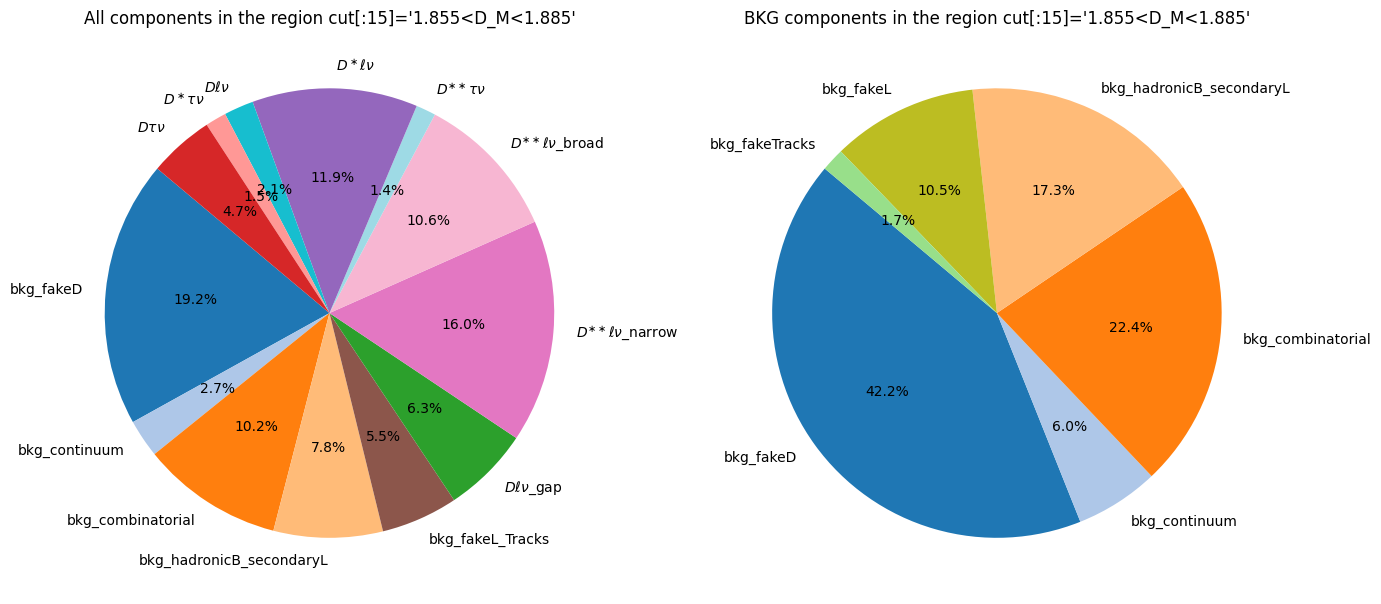

In [6]:
# new
mpl_mc.plot_pie(cut=f'1.855<D_M<1.885 and {lgb_tight} and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0) and B0_recMissM2>1 and p_D_l<3.5')

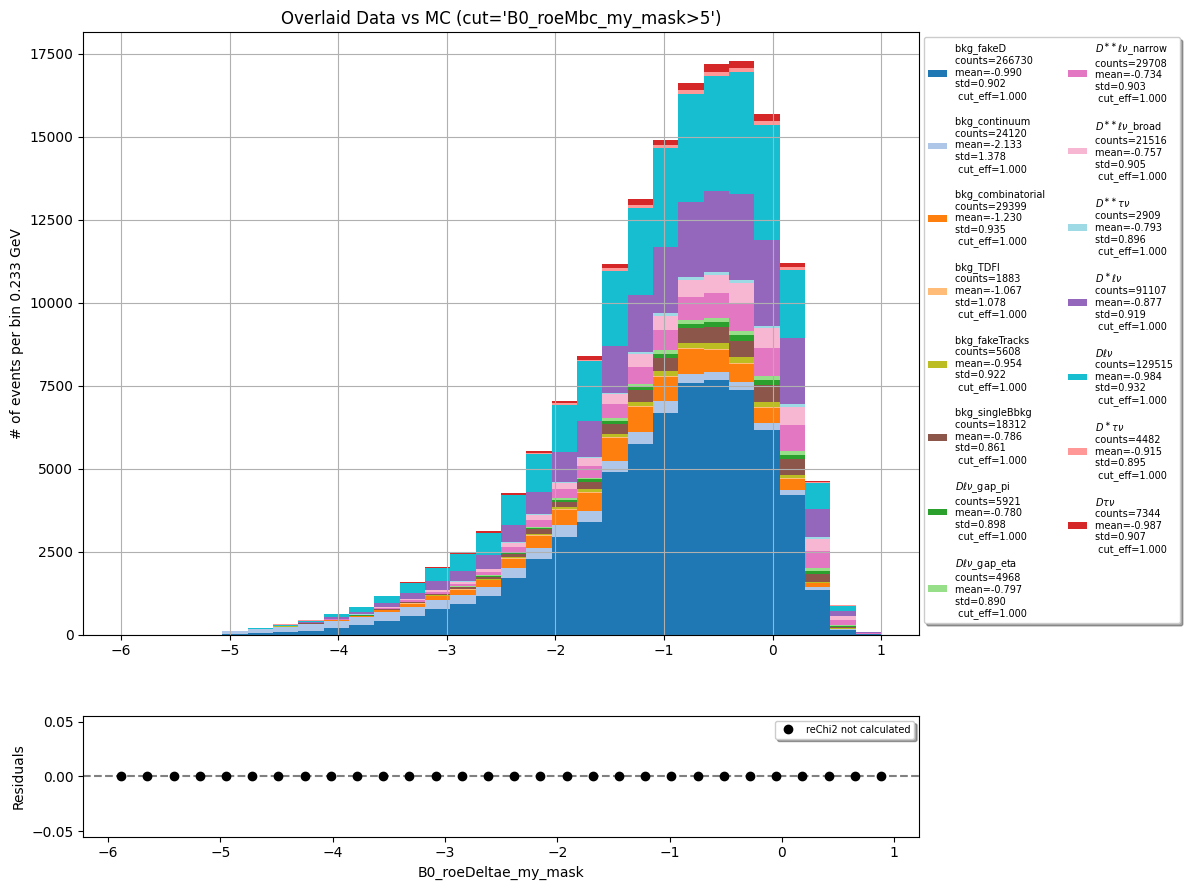

In [71]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(-6,1,31)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='B0_roeDeltae_my_mask',bins=b1,cut='B0_roeMbc_my_mask>5',correction=False,mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7, weights=weights)

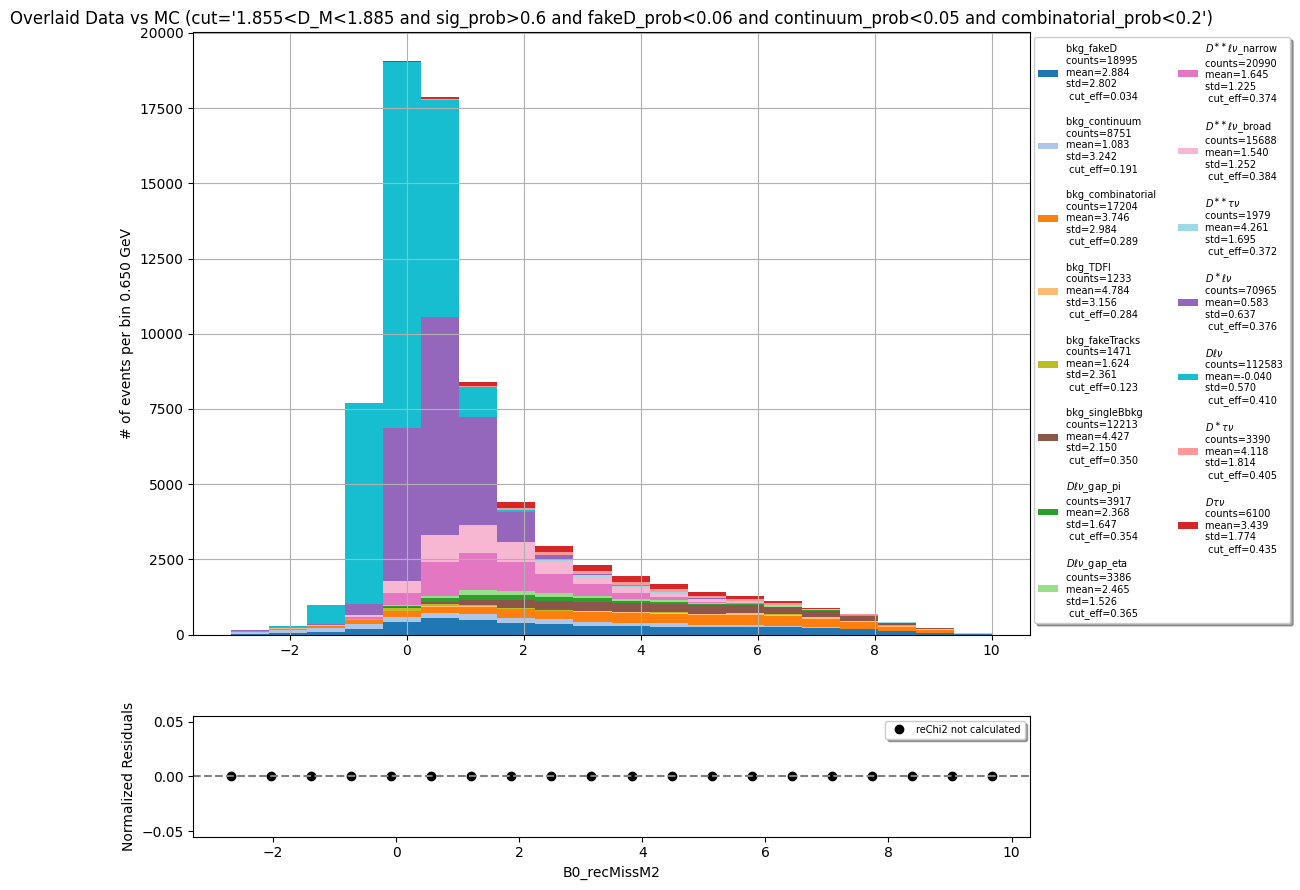

In [61]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(-3,10,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'1.855<D_M<1.885 and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PID_weight')

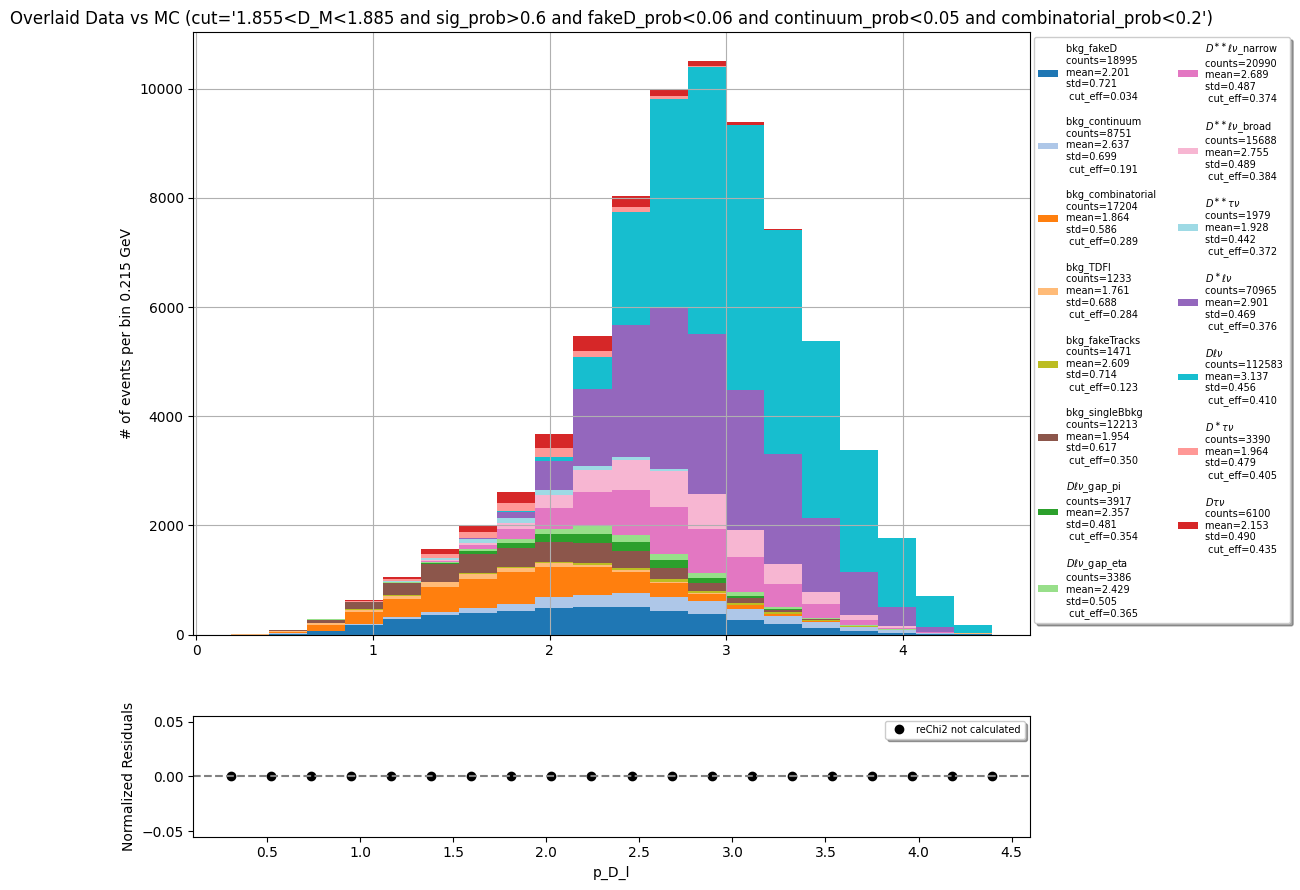

In [63]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(0.2,4.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'1.855<D_M<1.885 and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PID_weight')

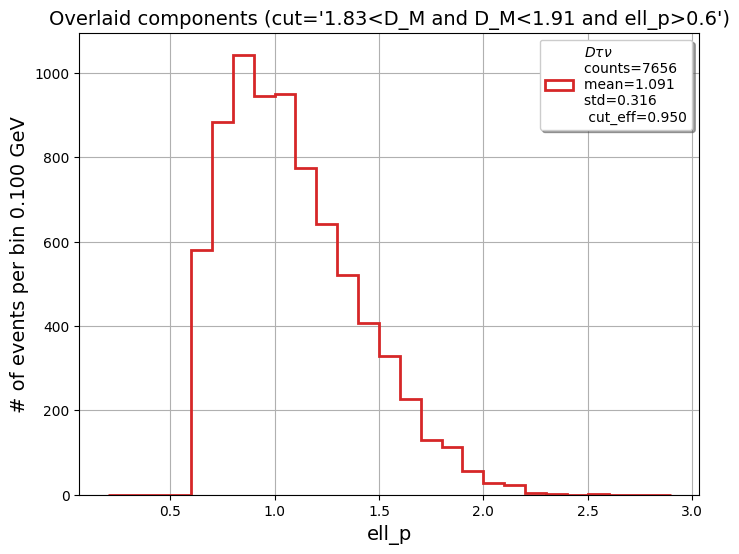

In [5]:
b1 = np.linspace(0.2,2.9,28)
comb_conpon = [r'$D\tau\nu$']
mpl_mc.plot_mc_1d_overlaid(variable='ell_p',bins=b1,mask=[],cut='1.83<D_M and D_M<1.91 and ell_p>0.6',
                        show_only=comb_conpon,density=False,legend_nc=2)

# Control regions
## 0. D_M sidebands

cut= (D_M<1.82 or 1.9<D_M) and sig_prob>0.6 and fakeD_prob<0.06 and continuum_prob<0.05 and combinatorial_prob<0.2


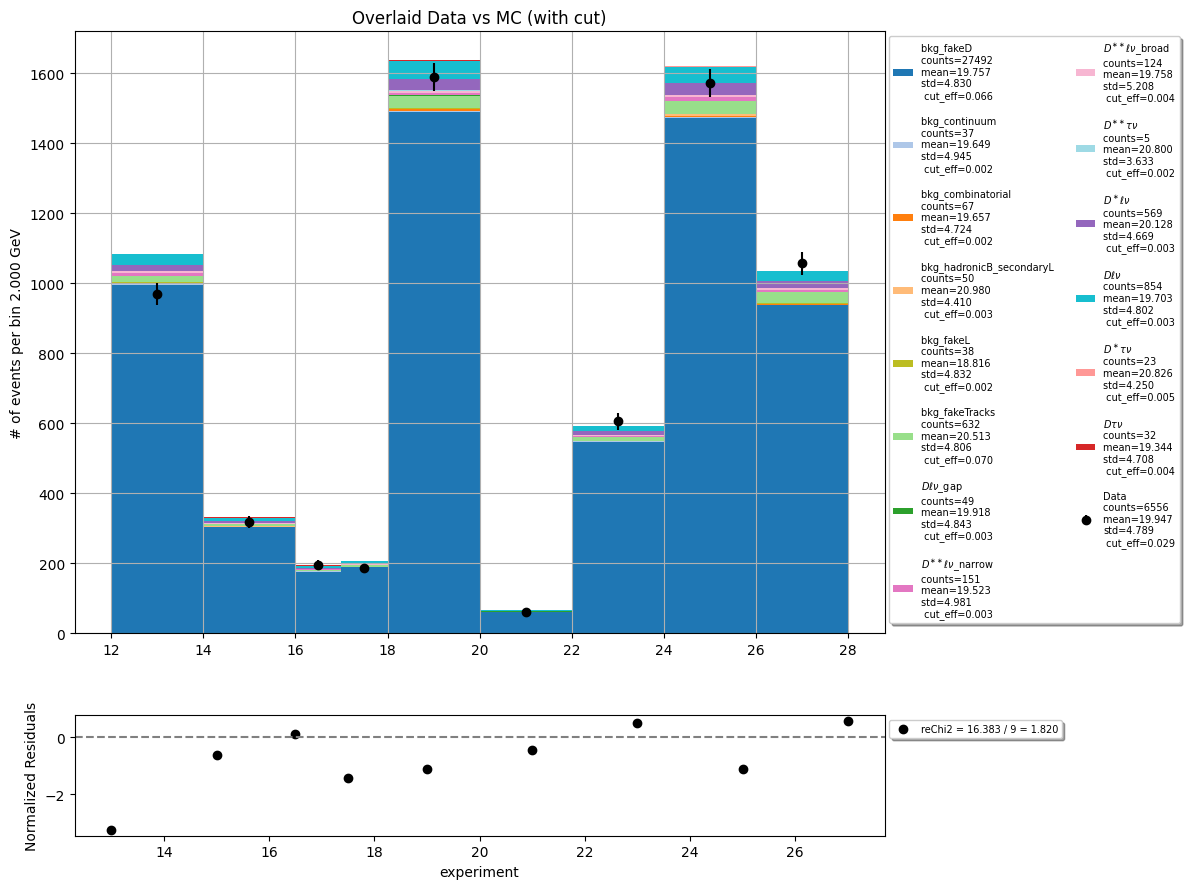

In [7]:
# new sample, new plot
b1 = np.array([12,14,16,17,18,20,22,24,26,28])
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='experiment',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_Weight')

cut= (D_M<1.82 or 1.9<D_M) and sig_prob>0.6 and fakeD_prob<0.06 and continuum_prob<0.05 and combinatorial_prob<0.2 and experiment<18


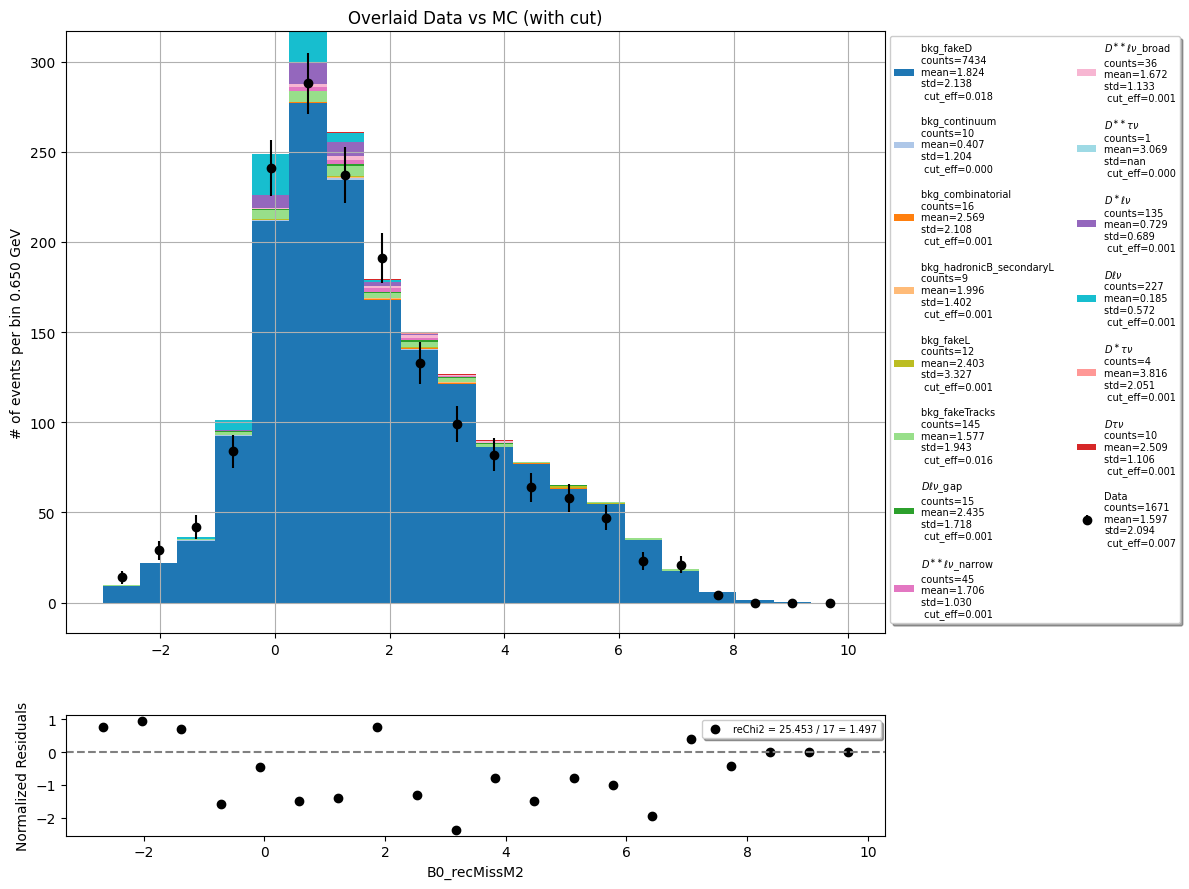

In [9]:
# new sample, new plot, exp<18
b1 = np.linspace(-3,10,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight} and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_Weight')

cut= (D_M<1.82 or 1.9<D_M) and sig_prob>0.6 and fakeD_prob<0.06 and continuum_prob<0.05 and combinatorial_prob<0.2 and experiment<18


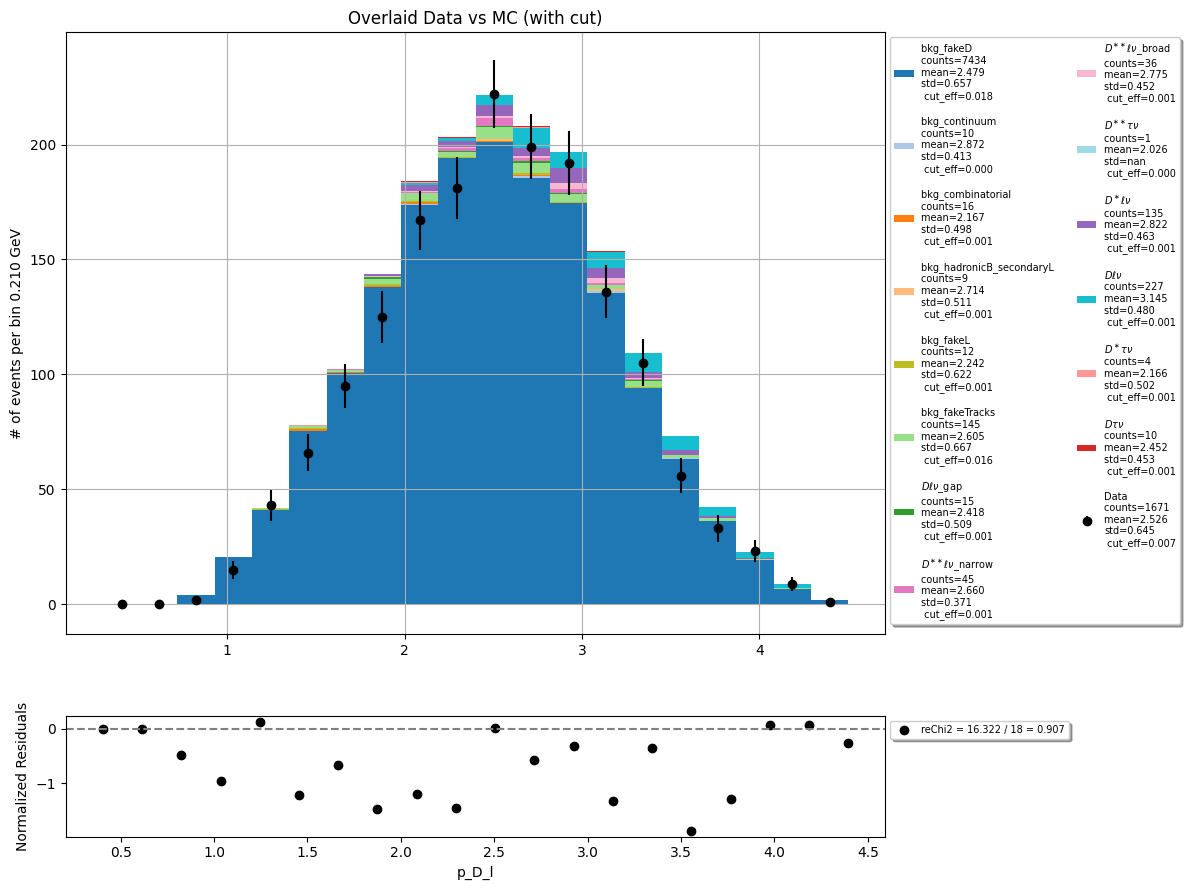

In [10]:
# new sample, new plot, exp<18
b1 = np.linspace(0.3,4.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight} and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_Weight')

## 1. q^2 < 3

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


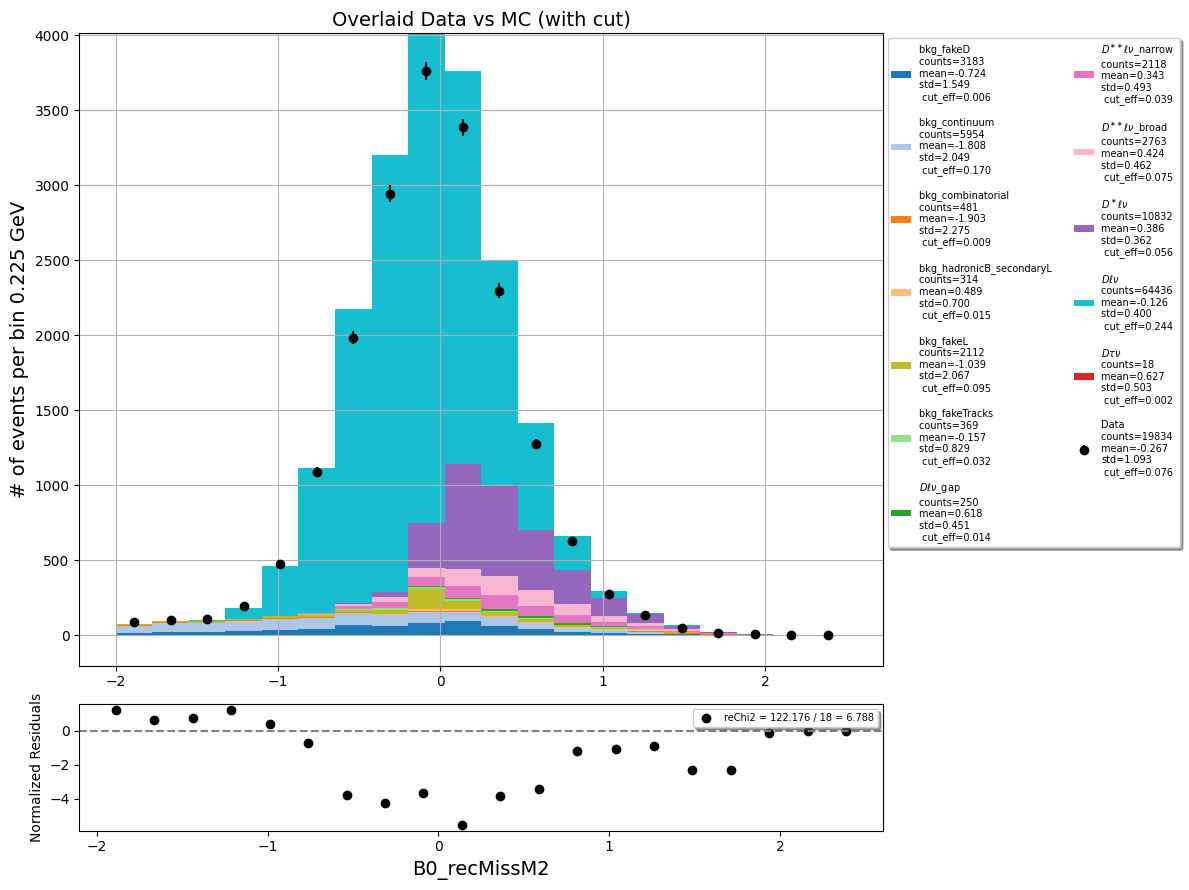

In [6]:
# new sample, new plot, exp < 18
b1 = np.linspace(-2,2.5,21)
weights={'all_mc':0.25*1.038,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


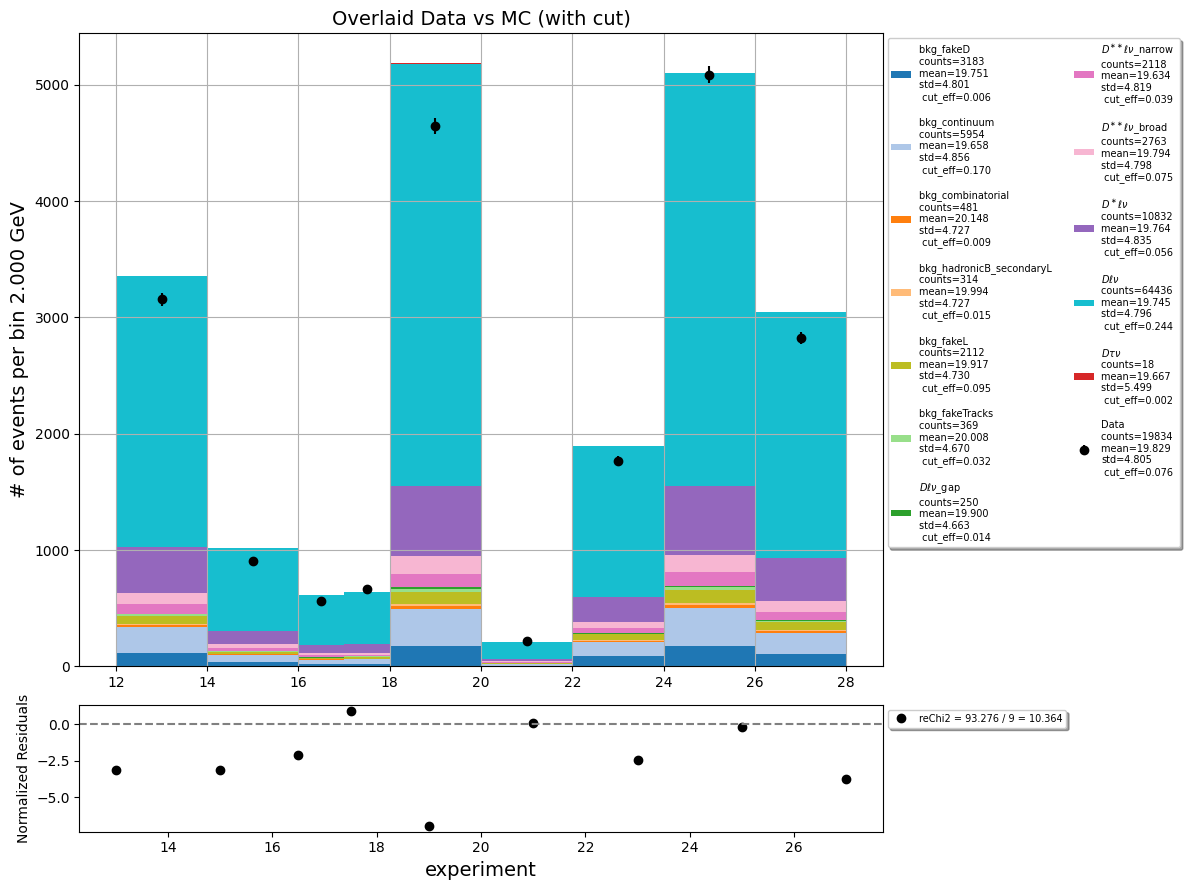

In [7]:
# new sample, new plot
b1 = np.array([12,14,16,17,18,20,22,24,26,28])
weights={'all_mc':0.25*1.038,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='experiment',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


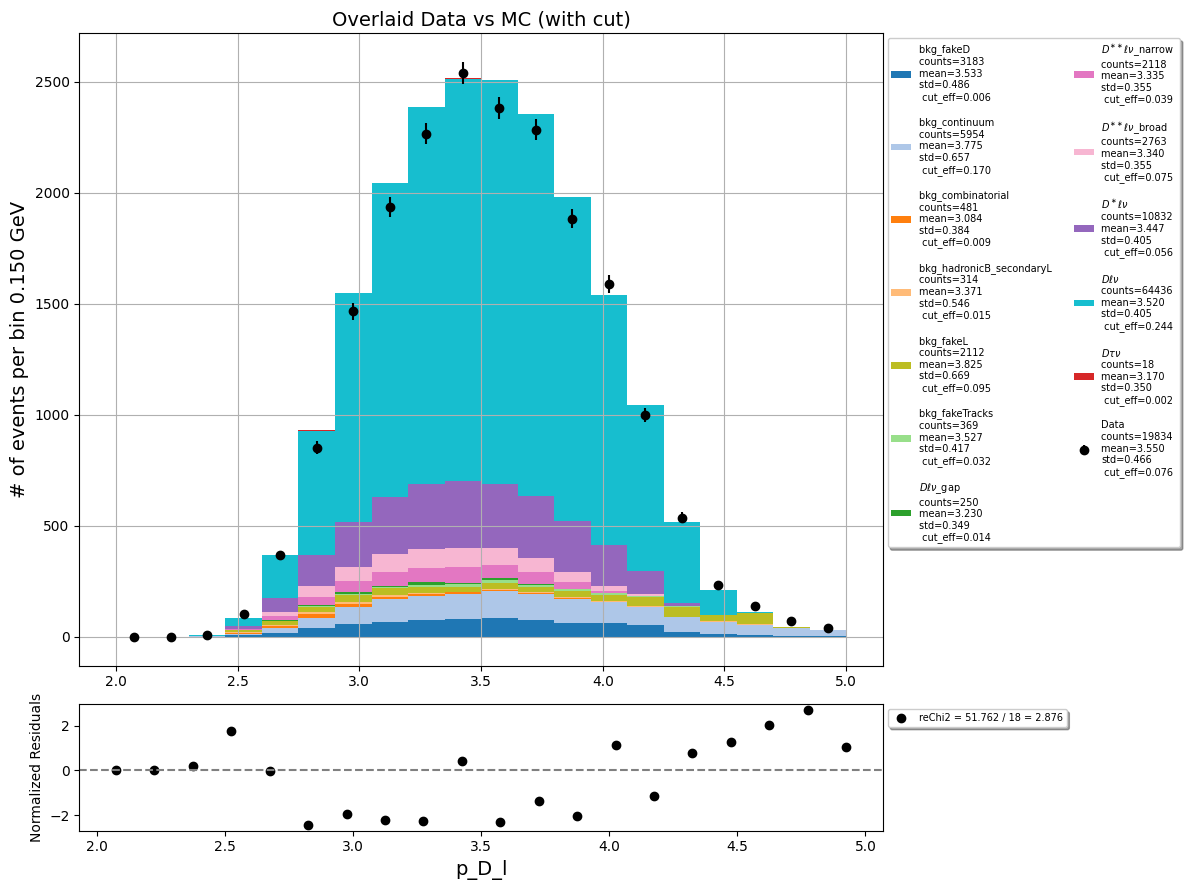

In [12]:
# new sample, new plot, exp<18
b1 = np.linspace(2,5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


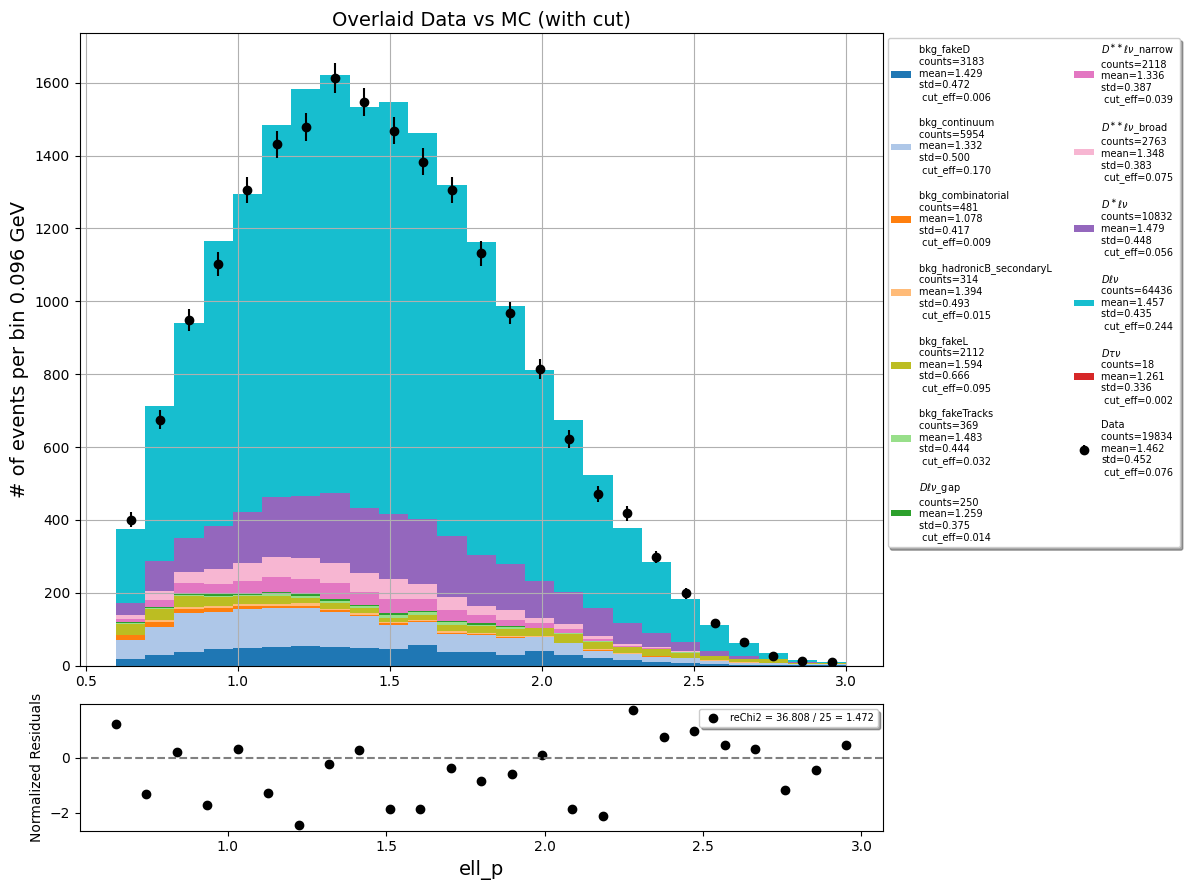

In [9]:
# new sample, new plot
b1 = np.linspace(0.6,3,26)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='ell_p',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885 and ell_p<1.5 and experiment==18


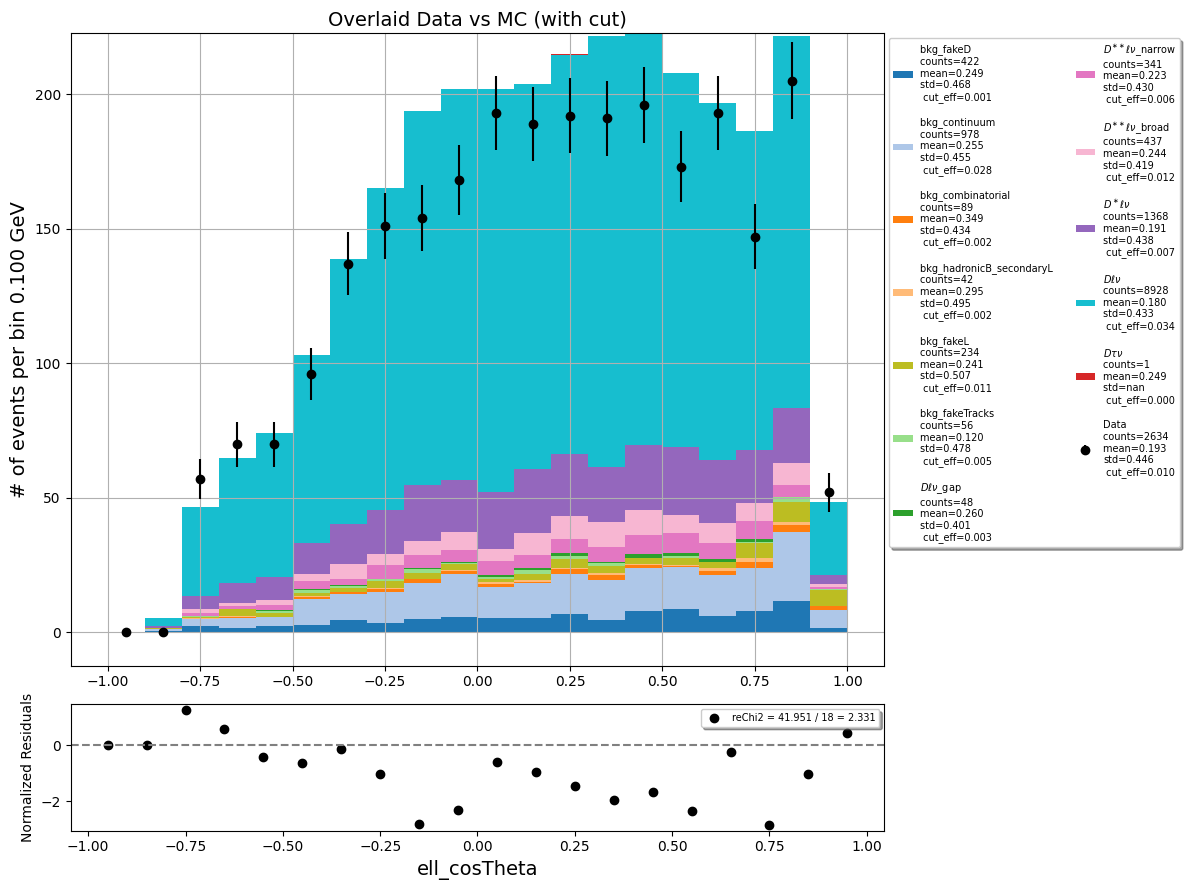

In [17]:
# new sample, new plot, exp<18
b1 = np.linspace(-1,1,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='ell_cosTheta',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885 and ell_p<1.5 and experiment==18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and experiment==26 and 1.855<D_M<1.885


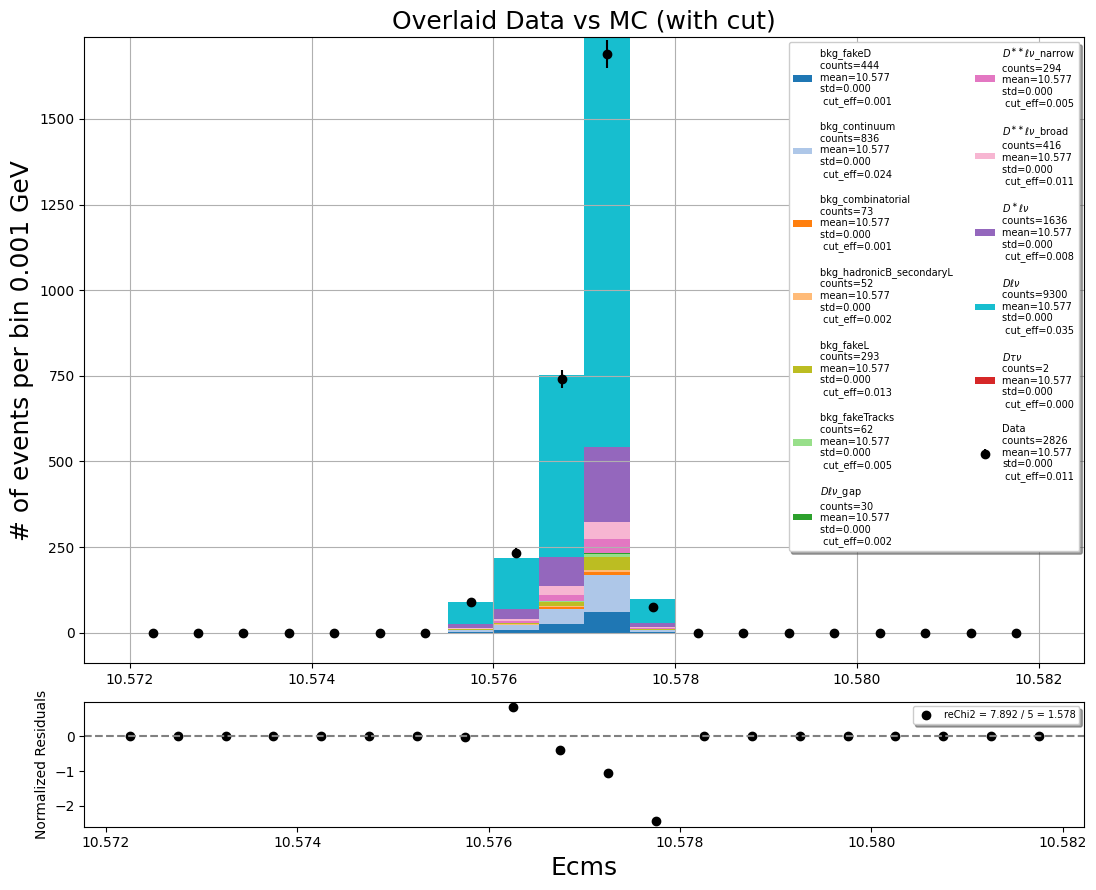

In [14]:
# new sample, new plot
b1 = np.linspace(10.572,10.582,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='Ecms',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and experiment==26 and 1.855<D_M<1.885',mask=[],
    figsize=(14,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6


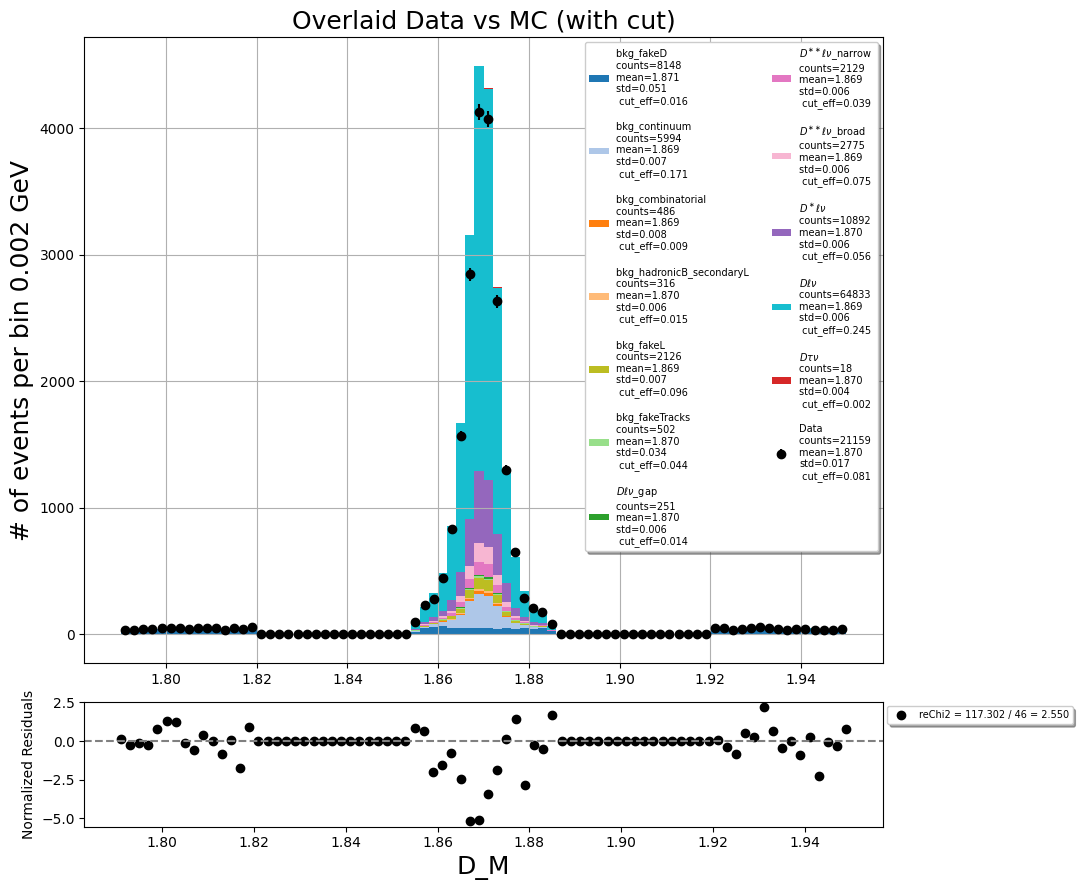

In [8]:
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25*1.038,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

### 1.1 Fit

In [9]:
# Create the bin edges
p_D_l_bins = np.concatenate(([0.4, 0.6, 0.8], 
                             np.linspace(1,3,41), 
                             [3.1, 3.2, 3.3, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6, 4.8]))

# Create the bin edges
MM2_bins = np.concatenate((np.linspace(-2.5,2.5,11), np.linspace(2.8,10,31) ) )

MM2_bins_sb = np.linspace(-2.5,10,21)
p_D_l_bins_sb = np.linspace(0.4,4.8,21)

# create templates
df_mc_4S_q2SB = df_mc_4S_loose.query(f'B0_recQ2BhSimple<3 and {lgb_tight}')
df_data_4S_q2SB = df_data_4S_loose.query(f'B0_recQ2BhSimple<3 and {lgb_tight}')
samples_q2SB=util.classify_mc_dict(df_mc_4S_q2SB, 'mu', template=False)

In [10]:
## MC16rd e
temp_data_mu_sr,temp_data_mu_sb,temp_data_mu_sr_merged, temp_data_mu_sb_merged = util.create_templates_new(
                    samples=samples_q2SB,
                    variables=['B0_recMissM2','p_D_l'], bin_threshold=10,merge_threshold=5,
                    bins_sr=[MM2_bins, p_D_l_bins], scale_lumi=1,
                    bins_sb=[MM2_bins_sb, p_D_l_bins_sb],
                    use_real_data_instead_of_asimov=True, real_data=df_data_4S_q2SB,
                    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight',
                    sample_to_exclude=['bkg_other_TDTl','bkg_other_signal',
                                      r'$D\ell\nu$_gap',
                                       # 'bkg_fakeD', 
                                       # 'bkg_continuum',
                #                       r'$D^{\ast\ast}\ell\nu$_broad',
                #                       r'$D^{\ast\ast}\ell\nu$_narrow',
                #                       r'$D\ell\nu$',
                #                       r'$D^\ast\ell\nu$',
                #                       r'$D\tau\nu$', 
                #                       r'$D^\ast\tau\nu$', 
                #                       r'$D^{\ast\ast}\tau\nu$',
                                      #  'bkg_fakeTracks',
                                      # 'bkg_TDFl','bkg_singleBbkg',
                                      # 'bkg_combinatorial',
                                      ],
                    sample_weights={r'$D\ell\nu$_gap':              0,  
                                    r'$D^{\ast\ast}\ell\nu$_broad': 0.25 * 1.435 * 1.038, # 11540 events from 1/ab
                                    r'$D^{\ast\ast}\ell\nu$_narrow':0.25 * 1.038,
                                    r'$D\ell\nu$':                  0.25 * 1.038,
                                    r'$D^\ast\ell\nu$':             0.25 * 1.038,
                                    r'$D\tau\nu$':                  0.25 * 1.038 , 
                                    r'$D^\ast\tau\nu$':             0.25 * 1.038 , 
                                    r'$D^{\ast\ast}\tau\nu$':       0.25 * 0.33 * 1.038,
                                    'bkg_fakeD':                    0.25 * 1.038, # here for signal region
                                    'bkg_TDFl':                     0.25 * 1.038,
                                    'bkg_continuum':                0.25 * 1.038,
                                    'bkg_combinatorial':            0.25 * 1.038,
                                    'bkg_singleBbkg':               0.25 * 1.038,
                                    'bkg_fakeTracks':               0.25 * 1.038,
                                    })

Creating templates for the signal region
Creating templates for D_M sidebands channel
creating new templates with merged bins in the signal region, original template length = 117, new template (merge small bins) length = 117
creating new templates with merged bins in the D mass sidebands, original template length = 33, new template (merge small bins) length = 33


In [11]:
import pyhf
import cabinetry
cabinetry.set_logging()
spec_mu_sb = util.create_workspace(temp_data_channels=[temp_data_mu_sr, temp_data_mu_sb], mc_uncer=True,fakeD_uncer=True)
spec_mu_sb['measurements'] = [{"name": "q2_sideband", "config": {"poi": "$D\\ell\\nu$_norm", "parameters": []}}]
model_mu_sb, data_mu_sb = cabinetry.model_utils.model_and_data(spec_mu_sb)

INFO - pyhf.workspace - Validating spec against schema: workspace.json
INFO - pyhf.pdf - Validating spec against schema: model.json
INFO - pyhf.pdf - adding modifier $D\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D\tau\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^\ast\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^{\ast\ast}\ell\nu$ + gap_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_fakeD_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_continuum_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier mcStat_ch0 (117 new nuisance parameters)
INFO - pyhf.pdf - adding modifier mcStat_ch1 (33 new nuisance parameters)


In [12]:
fit_results = cabinetry.fit.fit(model=model_mu_sb, data=data_mu_sb,goodness_of_fit=True,
                                fix_pars=[False, True]
                               )

INFO - cabinetry.fit - performing maximum likelihood fit
INFO - cabinetry.fit - Migrad status:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 648.1                      │             Nfcn = 29487             │
│ EDM = 8.3e-05 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴─────────────────────────────────

In [14]:
fitter = util.fit_Dmass(x_edges=b1, hist=data_hist_all, poly_only=True)
m_ml, c_ml, result_ml = fitter.fit_gauss_poly_ML(deg=1)
m_ml

initial parameters= [ 1.1850e+02  1.8700e+00  2.0000e-02  5.9268e+04  1.8180e+02 -9.3100e+01]


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 27.27 (χ²/ndof = 1.0)      │              Nfcn = 142              │
│ EDM = 3.82e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │    0.0    │    1.2    │            │            │    0    │         │  yes  │
│ 1 │ x1   │   1.870   │   0.019   │            │            │    0    │         │  yes  │
│ 2 │ x2   │  20.0e-3  │  0.2e-3   │            │            │    0    │         │  yes  │
│ 3 │ x3   │  19.80e3  │  0.23e3   │            │            │         │         │       │
│ 4 │ x4   │   0.1e3   │   0.7e3   │            │            │         │         │       │
│ 5 │ x5   │  -0.06e3  │  0.32e3   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────────────────────────────┐
│    │       x0       x1       x2       x3       x4       x5 │
├────┼───────────────────────────────────────────────────────┤
│ x0 │        0        0        0        0        0        0 │
│ x1 │        0        0        0        0        0        0 │
│ x2 │        0        0        0        0        0        0 │
│ x3 │        0        0        0 5.46e+04        0        0 │
│ x4 │        0        0        0        0 4.63e+05  -0.22e6 │
│ x5 │        0        0        0        0  -0.22e6 1.05e+05 │
└────┴───────────────────────────────────────────────────────┘

In [15]:
yields_left = fitter.poly_integral(xrange=[1.79,1.82],result=result_ml)
yields_sig = fitter.poly_integral(xrange=[1.855,1.885],result=result_ml)
yields_right = fitter.poly_integral(xrange=[1.92,1.95],result=result_ml)

Yields from 1.79 to 1.82 = 3540.042 ± 61.021
Yields from 1.855 to 1.885 = 3713.238 ± 43.813
Yields from 1.92 to 1.95 = 3886.433 ± 62.279


In [17]:
a = len(df_data_4S_loose.query('1.79<D_M<1.82 and B0_recQ2BhSimple<3'))
b = len(df_data_4S_loose.query('1.92<D_M<1.95 and B0_recQ2BhSimple<3'))
print('data', a,b)

data 3532 3881


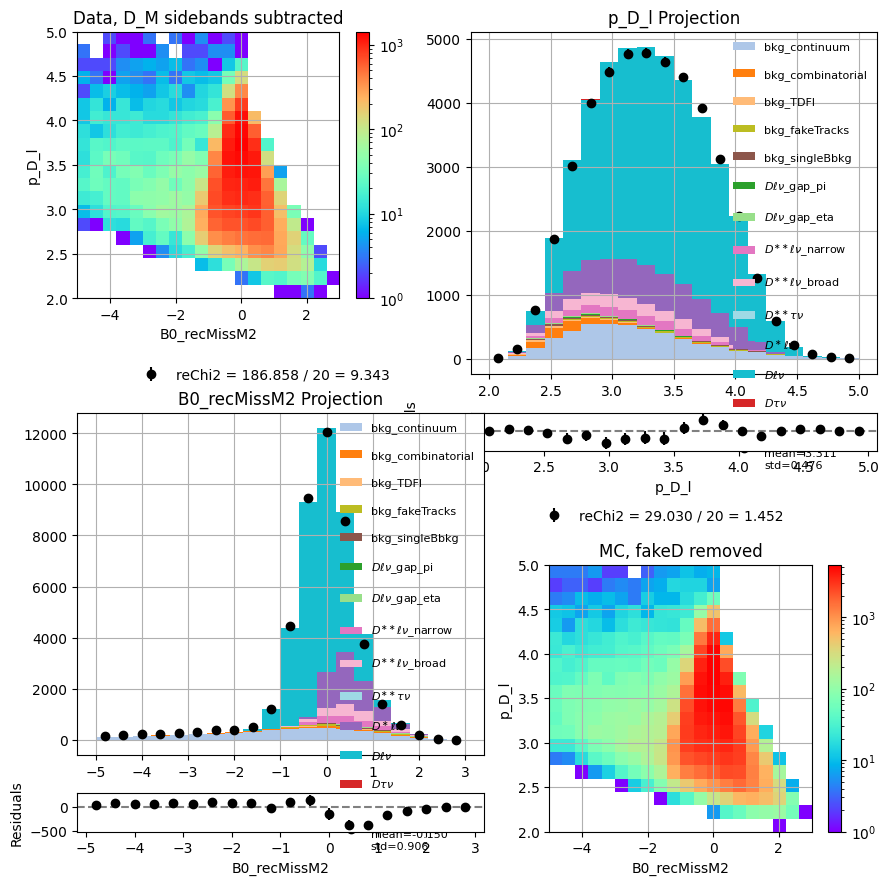

In [21]:
# e channel, lgb_loose
b_mm2 = np.linspace(-5,3,21)
b_pDl = np.linspace(2,5,21)
scale2 = {'data left sideband': 1550/1466/2,
         'data right sideband': 1550/1635/2,
         'data signal region': 1,
         'all_mc': 0.25}

par_dict={'var_list':['B0_recMissM2','p_D_l'],
          'bin_list': [b_mm2, b_pDl],
          'cut': 'B0_recQ2BhSimple<3', #'B0_roeMbc_my_mask>5.1 and -4<B0_roeDeltae_my_mask<1',
          'weights': scale2,
          'correction': False,
          'mask': ['bkg_fakeD']}
indices_threshold, temp_data = mpl.plot_data_subtracted_and_mc(**par_dict)

## 2. D* veto

In [ ]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.23,'bkg_singleBbkg':0.14*23/25,'HadronicB2D_SecondaryLepton': 0.1*23/25,}
data_hist_all, mc_hist_all = mpl_subcat.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut='0.135<DstVeto_massDiff_0<0.145',correction=False,mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=6,weights=weights)

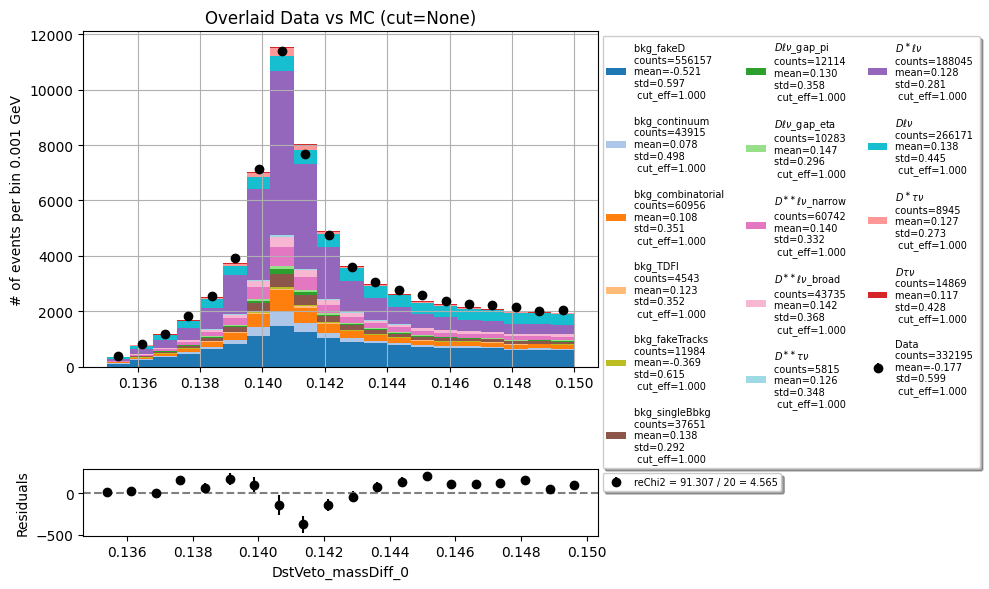

In [51]:
# e channel
b1 = np.linspace(0.135,0.15,21)
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='DstVeto_massDiff_0',bins=b1,cut=None,
    correction=False,mask=[],figsize=(10,6),ratio=False,
    weights={'all_mc':0.22},legend_nc=3, legend_fs=7)

cut= sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 0<B0_recMissM2<3 and 1.855<D_M<1.885 and 0.135<DstVeto_massDiff_0<0.145


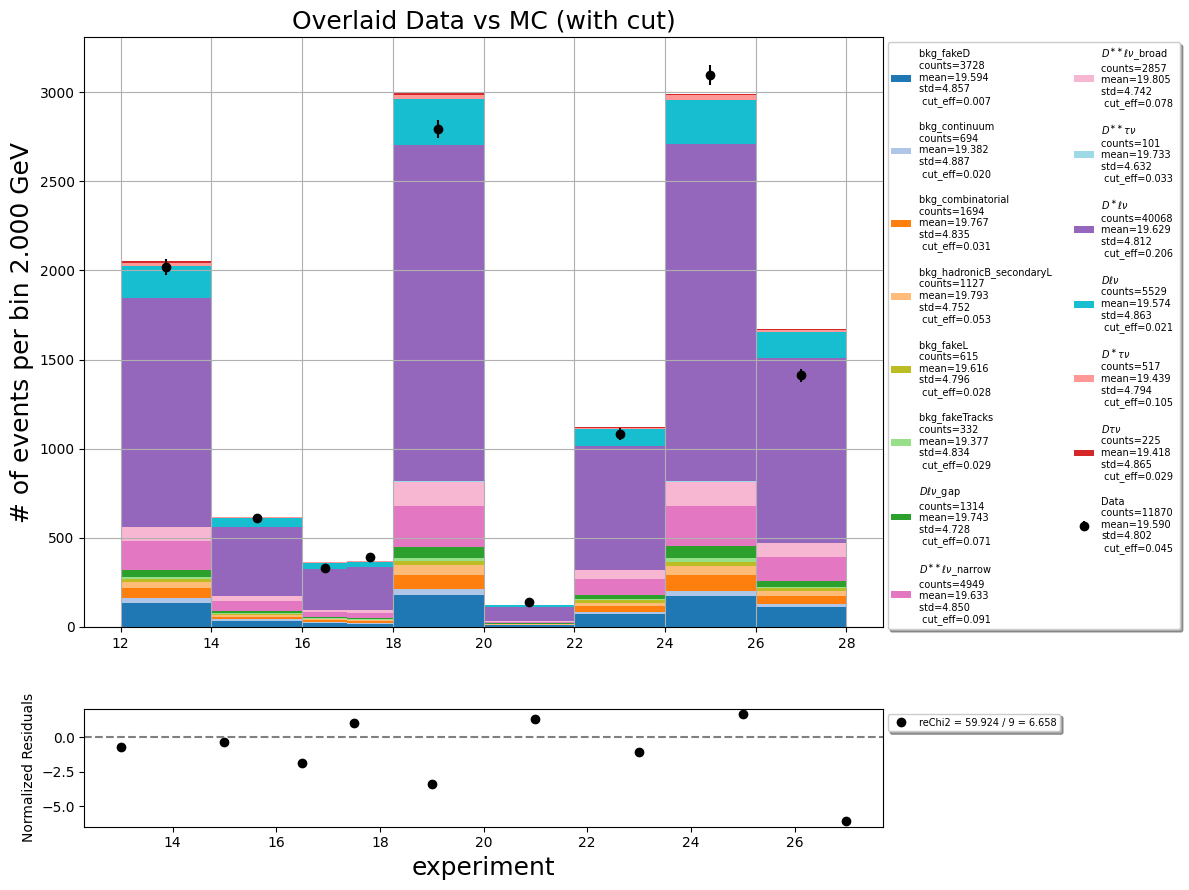

In [14]:
# new sample, new plot, new BDT
b1 = np.array([12,14,16,17,18,20,22,24,26,28])
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='experiment',bins=b1,cut=f'{lgb_tight} and 0<B0_recMissM2<3 and 1.855<D_M<1.885 and 0.135<DstVeto_massDiff_0<0.145',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= 0.135<DstVeto_massDiff_0<0.145 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885 and experiment<18


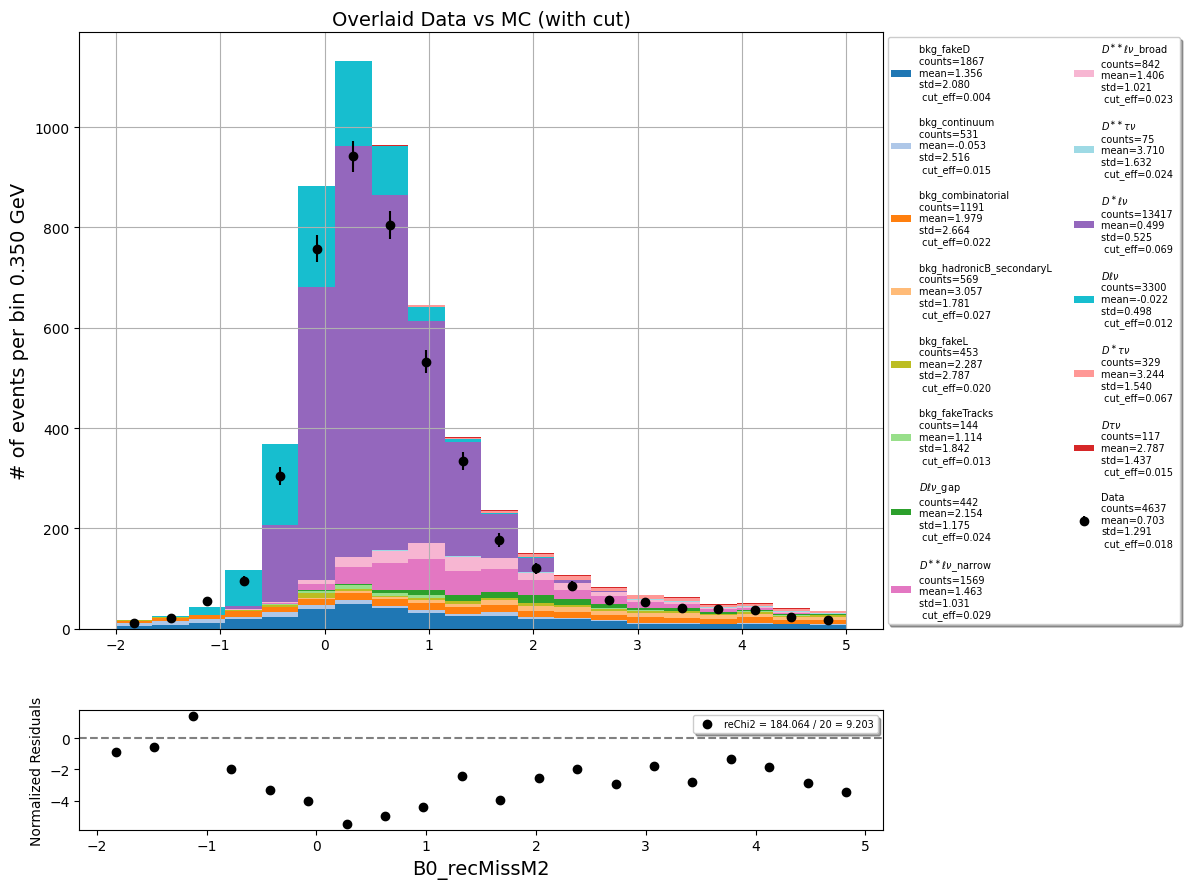

In [18]:
# exp<18
b1 = np.linspace(-2,5,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'0.135<DstVeto_massDiff_0<0.145 and {lgb_tight} and 1.855<D_M<1.885 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_Weight')

cut= 0.135<DstVeto_massDiff_0<0.145 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


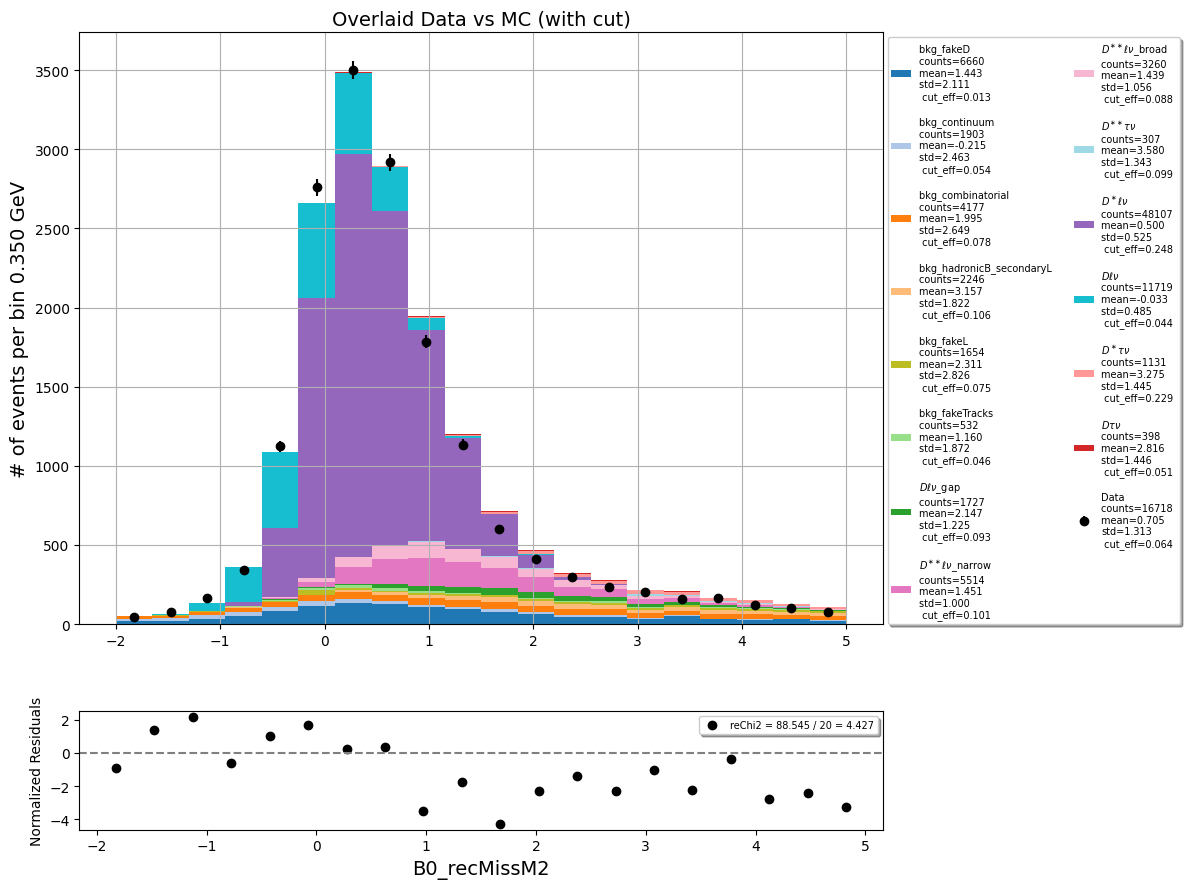

In [15]:
# exp<18
b1 = np.linspace(-2,5,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'0.135<DstVeto_massDiff_0<0.145 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 0<B0_recMissM2<3 and 0.135<DstVeto_massDiff_0<0.145


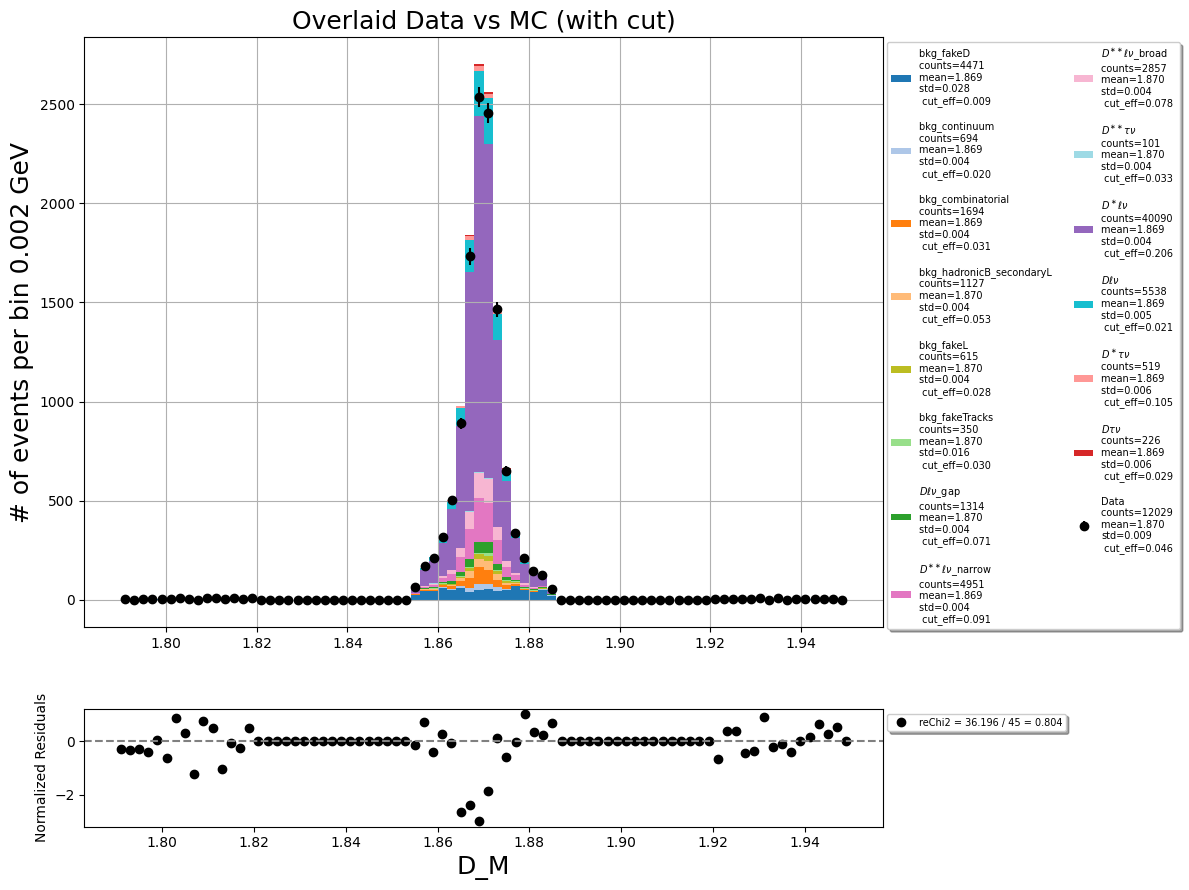

In [16]:
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut=f'{lgb_tight} and 0<B0_recMissM2<3 and 0.135<DstVeto_massDiff_0<0.145',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')